# TeleScent — Scent Classification (no_scent · sweet_orange · peppermint)

This notebook trains and evaluates the TeleScent scent classifier end-to-end on
the labelled dataset at `ml/sensor_data.csv`. It is the executable companion to
the academic report.

**Methodology in one paragraph.** A single Bosch BME688 metal-oxide gas sensor
produces nine raw channels per reading. We engineer 13 additional features that
encode ratios and interactions between the chemical channels (motivated by
gas-sensor literature on differential response patterns). Four model families
are compared head-to-head — Random Forest, Histogram Gradient Boosting (both
tree ensembles), a Multi-Layer Perceptron from scikit-learn, and a hand-built
PyTorch feed-forward neural network with batch normalisation and dropout
(reported separately so the report can discuss training dynamics). Because the
dataset consists of long consecutive reads grouped into 9 sessions, all
splits use `StratifiedGroupKFold` over `Session ID` to prevent the trivial
leakage that comes from putting near-duplicate adjacent rows on both sides
of the split. We hold out one moderate-sized session per class as a final
test set and report macro-F1 as the primary metric, since the peppermint
class is severely under-represented (~10% of rows).

**Reproducibility.** Random seed = 42 throughout. Run all cells top-to-bottom.

## 0. Setup & Imports

In [1]:
from __future__ import annotations
import json, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import sklearn
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

import sys
ML_DIR = Path.cwd() if Path.cwd().name == "ml" else Path.cwd() / "ml"
if str(ML_DIR.parent) not in sys.path:
    sys.path.insert(0, str(ML_DIR.parent))

from ml.data_loader import (load_dataset, holdout_test_sessions,
                            grouped_cv_splitter, DEFAULT_CLASSES)
from ml.features import ScentFeatureBuilder

SEED = 42
random.seed(SEED); np.random.seed(SEED)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(context="notebook", style="whitegrid")
MODEL_DIR = ML_DIR / "model"
EVAL_DIR  = MODEL_DIR / "eval"
MODEL_DIR.mkdir(exist_ok=True); EVAL_DIR.mkdir(exist_ok=True)
print(f"scikit-learn {sklearn.__version__} | seed {SEED}")
print(f"output dir   {MODEL_DIR}")

scikit-learn 1.7.2 | seed 42
output dir   /home/klaus/TeleScent/ml/model


## 1. Load the labelled dataset

The CSV contains every reading the data-collection client has stored,
labelled in three phases (`stabilisation` / `exposure` / `recovery`).
Recovery readings are labelled `no_scent` because the protocol verifies
return-to-baseline before declaring recovery complete (see report §4).

In [2]:
ds = load_dataset(classes=DEFAULT_CLASSES)
print(f"Total rows: {len(ds)}")
print(f"Sessions:   {ds.groups.nunique()}")
print(f"Features kept ({len(ds.X.columns)}): {list(ds.X.columns)}")
print("\nClass counts:")
print(ds.class_counts())

Total rows: 998
Sessions:   9
Features kept (9): ['Sensor 0', 'Sensor 1', 'Sensor 3', 'Sensor 4', 'Sensor 5', 'Ethanol', 'CoH2', 'VocRaw', 'NoxRaw']

Class counts:
Scent
no_scent        399
peppermint      372
sweet_orange    227
Name: count, dtype: int64


### 1.1 Session × class matrix

The dataset has only 9 sessions. Class imbalance is *between* sessions
as well as overall: peppermint appears in just 3 sessions. Any random
row-level split would leak adjacent readings into both train and test —
the consecutive duplicate rows visible in the raw CSV confirm this. We
therefore split by `Session ID`.

In [3]:
session_table = pd.crosstab(ds.groups, ds.y, margins=True, margins_name="Total")
session_table

Scent,no_scent,peppermint,sweet_orange,Total
Session ID,,,,
20260309_1313_session_01,117,0,77,194
20260309_1411_session_02,10,0,30,40
20260422_1346_no_scent_01,10,0,0,10
20260422_1346_session_03,80,0,60,140
20260422_1611_session_04,40,0,60,100
20260512_1011_peppermint_01,0,10,0,10
20260512_1020_peppermint_01,80,2,0,82
20260512_1216_peppermint_02,46,360,0,406
20260512_1327_peppermint_03,16,0,0,16


### 1.2 Per-class sensor distributions

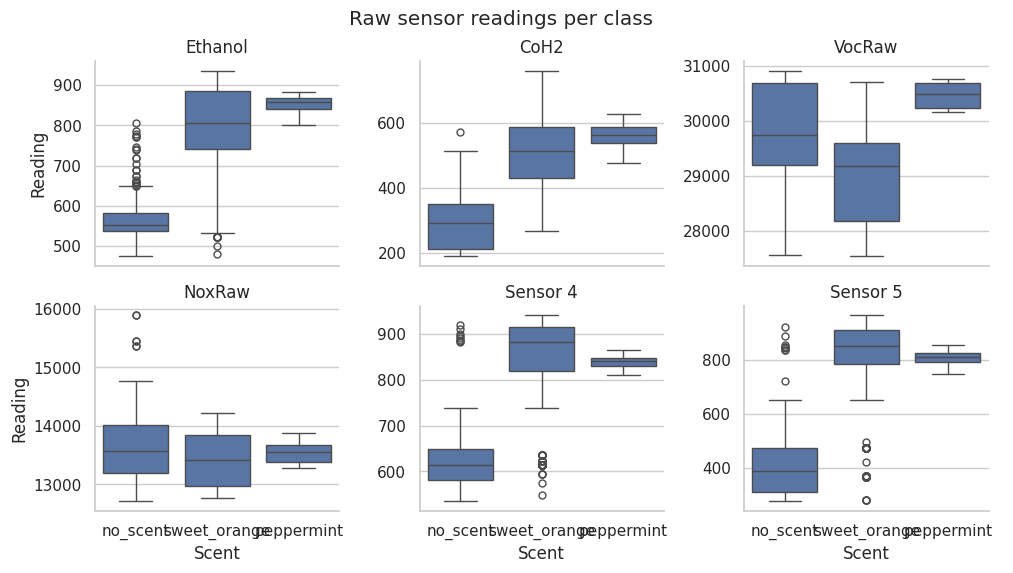

In [4]:
sample_cols = ["Ethanol", "CoH2", "VocRaw", "NoxRaw", "Sensor 4", "Sensor 5"]
sample_cols = [c for c in sample_cols if c in ds.X.columns]
plot_df = ds.X[sample_cols].copy()
plot_df["Scent"] = ds.y.values
melted = plot_df.melt(id_vars="Scent", var_name="Sensor", value_name="Reading")

g = sns.catplot(data=melted, x="Scent", y="Reading", col="Sensor",
                col_wrap=3, kind="box", sharey=False, height=2.8, aspect=1.2)
g.set_titles("{col_name}")
g.fig.suptitle("Raw sensor readings per class", y=1.02)
plt.show()

## 2. Group-aware splits

- **Final test set:** one session per class, chosen deterministically so
  the test size is closest to 20% of the class.
- **Cross-validation on the remainder:** `StratifiedGroupKFold(k=5)`,
  groups = `Session ID`, scoring = macro-F1.

In [5]:
train_idx, test_idx = holdout_test_sessions(ds, target_frac=0.20, random_state=SEED)
X_train_raw = ds.X.iloc[train_idx].reset_index(drop=True)
X_test_raw  = ds.X.iloc[test_idx].reset_index(drop=True)
y_train_str = ds.y.iloc[train_idx].reset_index(drop=True)
y_test_str  = ds.y.iloc[test_idx].reset_index(drop=True)
groups_train = ds.groups.iloc[train_idx].reset_index(drop=True)

le = LabelEncoder().fit(sorted(ds.y.unique()))
y_train = le.transform(y_train_str)
y_test  = le.transform(y_test_str)
class_names = list(le.classes_)

print(f"Train rows: {len(train_idx)} | Test rows: {len(test_idx)}")
print("Test sessions:", sorted(ds.groups.iloc[test_idx].unique()))
print("Train class dist:", pd.Series(y_train_str).value_counts().to_dict())
print("Test  class dist:", pd.Series(y_test_str).value_counts().to_dict())
cv = grouped_cv_splitter(n_splits=5, random_state=SEED)

Train rows: 808 | Test rows: 190
Test sessions: ['20260309_1411_session_02', '20260422_1346_session_03', '20260512_1011_peppermint_01']
Train class dist: {'peppermint': 362, 'no_scent': 309, 'sweet_orange': 137}
Test  class dist: {'no_scent': 90, 'sweet_orange': 90, 'peppermint': 10}


## 3. Pipelines

A single `sklearn.Pipeline` per model bundles preprocessing + classifier so
the exact same transforms apply at inference time (called from `serve.py`).

Steps inside every pipeline:

1. **`ScentFeatureBuilder`** — adds engineered chemistry features (ratios,
   interactions, log-raw values). Defined in `ml/features.py`.
2. **`SimpleImputer(strategy="median")`** — handles any missing sensor.
3. **`StandardScaler`** — necessary for the MLP, harmless for trees.
4. Classifier — Random Forest / Hist Gradient Boosting / MLP.

`class_weight="balanced"` is used everywhere a classifier accepts it
(RF, MLP). HGB does not expose `class_weight`, so we pass per-sample
weights via `sample_weight` at fit time. SMOTE oversampling is compared
separately in §6.

In [6]:
def make_pipeline(classifier) -> Pipeline:
    return Pipeline([
        ("features", ScentFeatureBuilder()),
        ("imputer",  SimpleImputer(strategy="median")),
        ("scaler",   StandardScaler()),
        ("clf",      classifier),
    ])

PIPELINES = {
    "random_forest": make_pipeline(RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        class_weight="balanced", random_state=SEED, n_jobs=-1)),
    "hist_gbm": make_pipeline(HistGradientBoostingClassifier(
        max_depth=None, learning_rate=0.08, max_iter=300,
        random_state=SEED)),
    "mlp": make_pipeline(MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu",
        alpha=1e-3, early_stopping=True, max_iter=500,
        random_state=SEED)),
}
list(PIPELINES.keys())

['random_forest', 'hist_gbm', 'mlp']

## 4. Cross-validated comparison (macro-F1)

Run all three pipelines through the same `StratifiedGroupKFold` and tabulate
mean ± std for accuracy, macro-F1, and per-class recall.

In [7]:
def compute_sample_weight(y_arr):
    classes, counts = np.unique(y_arr, return_counts=True)
    weight = {c: len(y_arr) / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
    return np.array([weight[v] for v in y_arr])

def cv_run(name, pipe):
    scoring = {
        "acc":          "accuracy",
        "f1_macro":     "f1_macro",
        "recall_macro": "recall_macro",
    }
    fit_params = {}
    if name == "hist_gbm":
        fit_params = {"clf__sample_weight": compute_sample_weight(y_train)}
    res = cross_validate(pipe, X_train_raw, y_train, cv=cv,
                         groups=groups_train, scoring=scoring,
                         return_train_score=False, n_jobs=1,
                         params=fit_params if fit_params else None)
    return {k: (res[f"test_{k}"].mean(), res[f"test_{k}"].std())
            for k in scoring}

cv_results = {}
for name, pipe in PIPELINES.items():
    t0 = time.perf_counter()
    cv_results[name] = cv_run(name, pipe)
    print(f"{name:<14} done in {time.perf_counter()-t0:5.1f}s")

cv_table = pd.DataFrame({
    name: {f"{m} ({stat})": (v[0] if stat == "mean" else v[1])
           for m, v in metrics.items() for stat in ("mean", "std")}
    for name, metrics in cv_results.items()
}).T
cv_table = cv_table.round(4)
cv_table

random_forest  done in   1.9s
hist_gbm       done in   3.6s
mlp            done in   0.2s


,acc (mean),acc (std),f1_macro (mean),f1_macro (std),recall_macro (mean),recall_macro (std)
random_forest,0.7956,0.1824,0.6635,0.2936,0.6667,0.2845
hist_gbm,0.6150,0.3436,0.6154,0.3145,0.6011,0.3297
mlp,0.6332,0.3398,0.5743,0.3483,0.5971,0.3290


### 4.1 Macro-F1 bar chart (Figure for report §8 Results)

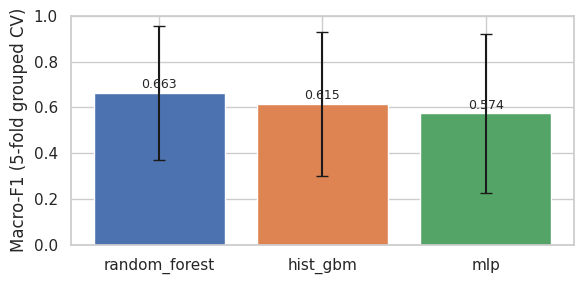

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
names = list(cv_results.keys())
means = [cv_results[n]["f1_macro"][0] for n in names]
stds  = [cv_results[n]["f1_macro"][1] for n in names]
ax.bar(names, means, yerr=stds, capsize=4, color=["#4c72b0", "#dd8452", "#55a467"])
ax.set_ylabel("Macro-F1 (5-fold grouped CV)")
ax.set_ylim(0, 1)
for i, m in enumerate(means):
    ax.text(i, m + 0.02, f"{m:.3f}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(EVAL_DIR / "cv_macro_f1.png", dpi=140)
plt.show()

## 5. Light hyperparameter search on each model

A small grid per model — ≤ 6 combinations — using the same grouped CV.

In [9]:
PARAM_GRIDS = {
    "random_forest": {
        "clf__n_estimators": [200, 400],
        "clf__min_samples_leaf": [1, 2, 4],
    },
    "hist_gbm": {
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_iter":      [200, 400],
    },
    "mlp": {
        "clf__hidden_layer_sizes": [(64,), (64, 32), (128, 64)],
        "clf__alpha":              [1e-4, 1e-3],
    },
}

tuned = {}
for name, pipe in PIPELINES.items():
    grid = PARAM_GRIDS[name]
    fit_params = {}
    if name == "hist_gbm":
        fit_params = {"clf__sample_weight": compute_sample_weight(y_train)}
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="f1_macro",
                      n_jobs=1, refit=True)
    gs.fit(X_train_raw, y_train, groups=groups_train, **fit_params)
    tuned[name] = gs
    print(f"{name:<14}  best macro-F1 = {gs.best_score_:.4f}  params={gs.best_params_}")

random_forest   best macro-F1 = 0.6683  params={'clf__min_samples_leaf': 4, 'clf__n_estimators': 200}
hist_gbm        best macro-F1 = 0.6111  params={'clf__learning_rate': 0.05, 'clf__max_iter': 200}
mlp             best macro-F1 = 0.5743  params={'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32)}


## 6. Class-imbalance ablation (peppermint focus)

Three strategies on the Random Forest pipeline:

- **A. baseline class_weight=balanced** (already in use)
- **B. SMOTE oversampling** of the training fold only
- **C. no rebalancing** (control)

Report each strategy's macro-F1 and the peppermint recall.

In [10]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

def smote_pipeline():
    return ImbPipeline([
        ("features", ScentFeatureBuilder()),
        ("imputer",  SimpleImputer(strategy="median")),
        ("scaler",   StandardScaler()),
        # k_neighbors=1 because one CV fold has only 2 peppermint samples
        ("smote",    SMOTE(random_state=SEED, k_neighbors=1)),
        ("clf",      RandomForestClassifier(
            n_estimators=300, random_state=SEED, n_jobs=-1)),
    ])

def plain_pipeline():
    return make_pipeline(RandomForestClassifier(
        n_estimators=300, random_state=SEED, n_jobs=-1))  # no class_weight

ablations = {
    "A_class_weight": PIPELINES["random_forest"],
    "B_smote":        smote_pipeline(),
    "C_no_rebalance": plain_pipeline(),
}

scoring = {"f1_macro": "f1_macro", "recall_pep": "recall_macro"}
abl_rows = []
for name, p in ablations.items():
    fold_f1, fold_pep = [], []
    for tr, va in cv.split(X_train_raw, y_train, groups=groups_train):
        p_ = p.__class__(steps=[(n, type(s)(**{k: v for k, v in s.get_params(deep=False).items() if not k.startswith('_')})
                                 if False else s) for n, s in p.steps])  # noqa - simple clone replacement
        # Simpler: just fit/predict on a fresh fit of the pipeline
        from sklearn.base import clone
        pc = clone(p)
        pc.fit(X_train_raw.iloc[tr], y_train[tr])
        pred = pc.predict(X_train_raw.iloc[va])
        fold_f1.append(f1_score(y_train[va], pred, average="macro"))
        pep_idx = list(le.classes_).index("peppermint")
        mask = y_train[va] == pep_idx
        if mask.sum():
            fold_pep.append((pred[mask] == pep_idx).mean())
        else:
            fold_pep.append(np.nan)
    abl_rows.append({
        "strategy":          name,
        "macro_f1_mean":     np.nanmean(fold_f1),
        "macro_f1_std":      np.nanstd(fold_f1),
        "peppermint_recall": np.nanmean(fold_pep),
    })
ablation_df = pd.DataFrame(abl_rows).round(4)
ablation_df

,strategy,macro_f1_mean,macro_f1_std,peppermint_recall
0,A_class_weight,0.6635,0.2936,0.8833
1,B_smote,0.6590,0.2944,0.8333
2,C_no_rebalance,0.6165,0.3135,0.5167


## 7. PyTorch feed-forward neural network

A small but explicit feed-forward network — the second model family alongside
the tree ensembles. Architecture (Figure for report §6 Methodology):

```
Input  (22 engineered features, standardised)
  │
  ├─ Linear(22, 64)  → BatchNorm1d → ReLU → Dropout(0.30)
  │
  ├─ Linear(64, 32)  → BatchNorm1d → ReLU → Dropout(0.30)
  │
  └─ Linear(32, 3)   → logits  (softmax applied by CrossEntropyLoss)
```

- **Loss:** weighted cross-entropy (`class_weight ∝ 1 / n_class`) to keep
  peppermint informative despite its 10% share.
- **Optimiser:** Adam, lr=1e-3, weight_decay=1e-4.
- **Regularisation:** dropout 0.3 + L2 weight decay + early stopping
  on validation macro-F1 (patience 20 epochs).
- **Training data flow:** the *fitted* preprocessing block from the best
  sklearn pipeline (features → impute → scale) is reused so the PyTorch
  model sees the same input space as the classical baselines. This is a
  fair-comparison choice, not a leak: the preprocessor is fit only on the
  fold's training rows.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.base import clone

torch.manual_seed(SEED)
DEVICE = torch.device("cpu")   # dataset is tiny; CPU is faster than GPU here.

N_FEATURES_ENG = len(ScentFeatureBuilder.OUT_COLS)
N_CLASSES = len(class_names)


class ScentNet(nn.Module):
    def __init__(self, in_dim=N_FEATURES_ENG, n_classes=N_CLASSES, p=0.30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_preprocessor():
    # Same preprocessing block as the sklearn pipelines, without classifier.
    return Pipeline([
        ("features", ScentFeatureBuilder()),
        ("imputer",  SimpleImputer(strategy="median")),
        ("scaler",   StandardScaler()),
    ])


def class_weight_tensor(y_arr):
    classes, counts = np.unique(y_arr, return_counts=True)
    w = len(y_arr) / (len(classes) * counts)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)


def train_torch(X_tr_arr, y_tr_arr, X_va_arr, y_va_arr,
                n_epochs=300, lr=1e-3, weight_decay=1e-4,
                batch_size=64, patience=20, verbose=False):
    # Train one ScentNet, return (model, history, best_val_f1).
    torch.manual_seed(SEED)
    X_tr = torch.tensor(X_tr_arr, dtype=torch.float32, device=DEVICE)
    y_tr = torch.tensor(y_tr_arr, dtype=torch.long,    device=DEVICE)
    X_va = torch.tensor(X_va_arr, dtype=torch.float32, device=DEVICE)
    y_va = torch.tensor(y_va_arr, dtype=torch.long,    device=DEVICE)

    model = ScentNet().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss(weight=class_weight_tensor(y_tr_arr))

    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    best_f1, best_state, bad_epochs = -1.0, None, 0

    n = len(X_tr)
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        running = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            if len(idx) < 2:    # BatchNorm requires ≥ 2 samples
                continue
            opt.zero_grad()
            logits = model(X_tr[idx])
            loss = loss_fn(logits, y_tr[idx])
            loss.backward()
            opt.step()
            running += loss.item() * len(idx)
        train_loss = running / max(1, n)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_va)
            val_loss = loss_fn(val_logits, y_va).item()
            val_pred = val_logits.argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_va_arr, val_pred, average="macro", zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        if val_f1 > best_f1 + 1e-4:
            best_f1, best_state, bad_epochs = val_f1, \
                {k: v.detach().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"   early stop at epoch {epoch}, best val_f1={best_f1:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_f1


# ─── Grouped CV with the PyTorch network ────────────────────────────────────
torch_fold_scores = []
torch_fold_history = []   # for plotting later
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_raw, y_train,
                                                 groups=groups_train)):
    pre = make_preprocessor().fit(X_train_raw.iloc[tr_idx])
    X_tr_arr = pre.transform(X_train_raw.iloc[tr_idx]).astype(np.float32)
    X_va_arr = pre.transform(X_train_raw.iloc[va_idx]).astype(np.float32)
    _, hist, best_val_f1 = train_torch(
        X_tr_arr, y_train[tr_idx], X_va_arr, y_train[va_idx])
    torch_fold_scores.append(best_val_f1)
    torch_fold_history.append(hist)
    print(f"  fold {fold + 1}: best val macro-F1 = {best_val_f1:.4f}  "
          f"(epochs={len(hist['val_f1'])})")

torch_cv_mean = float(np.mean(torch_fold_scores))
torch_cv_std  = float(np.std(torch_fold_scores))
print(f"\nPyTorch ScentNet — CV macro-F1 = {torch_cv_mean:.4f} ± {torch_cv_std:.4f}")

# Append to the comparison table built in §4
cv_results["pytorch_mlp"] = {
    "acc":          (float(np.nan), float(np.nan)),
    "f1_macro":     (torch_cv_mean, torch_cv_std),
    "recall_macro": (float(np.nan), float(np.nan)),
}

  fold 1: best val macro-F1 = 0.6296  (epochs=71)
  fold 2: best val macro-F1 = 0.3762  (epochs=21)
  fold 3: best val macro-F1 = 1.0000  (epochs=21)
  fold 4: best val macro-F1 = 1.0000  (epochs=27)
  fold 5: best val macro-F1 = 0.5635  (epochs=22)

PyTorch ScentNet — CV macro-F1 = 0.7139 ± 0.2480


### 7.1 Training curves (longest fold)

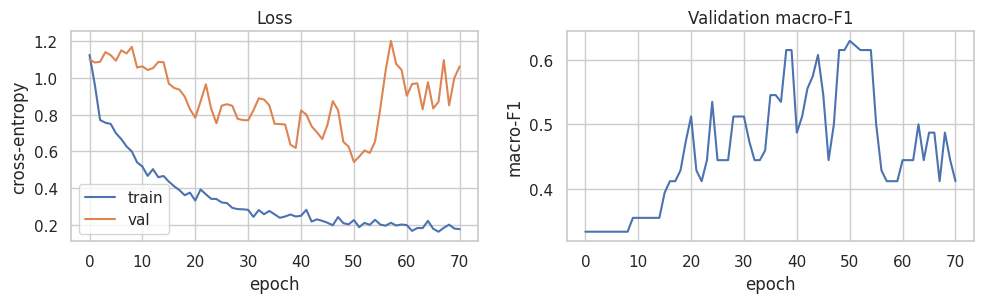

In [12]:
longest = max(torch_fold_history, key=lambda h: len(h["val_f1"]))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(longest["train_loss"], label="train")
axes[0].plot(longest["val_loss"],   label="val")
axes[0].set(title="Loss", xlabel="epoch", ylabel="cross-entropy"); axes[0].legend()
axes[1].plot(longest["val_f1"])
axes[1].set(title="Validation macro-F1", xlabel="epoch", ylabel="macro-F1")
fig.tight_layout()
fig.savefig(EVAL_DIR / "pytorch_training_curves.png", dpi=140)
plt.show()

### 7.2 Final PyTorch model — train on full train set, evaluate on holdout

`TorchPredictor` wraps the trained network with `predict` and
`predict_proba` so it can flow through the same evaluation code as the
sklearn pipelines in §8.

   early stop at epoch 30, best val_f1=0.3762
Final PyTorch model — best internal val macro-F1 = 0.3762

PyTorch ScentNet — holdout macro-F1 = 0.4217
              precision    recall  f1-score   support

    no_scent       0.58      0.89      0.70        90
  peppermint       0.00      0.00      0.00        10
sweet_orange       0.77      0.44      0.56        90

    accuracy                           0.63       190
   macro avg       0.45      0.44      0.42       190
weighted avg       0.64      0.63      0.60       190



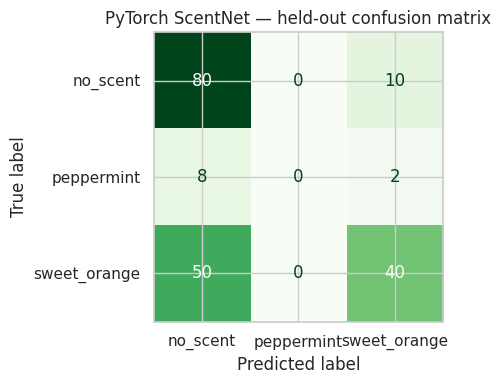

In [13]:
class TorchPredictor:
    # sklearn-compatible adapter around (preprocessor + ScentNet).
    _estimator_type = "classifier"

    def __init__(self, preprocessor, model, classes_):
        self.preprocessor = preprocessor
        self.model = model.eval()
        self.classes_ = np.arange(len(classes_))   # numeric labels for sklearn
        self.class_names_ = list(classes_)

    # No-op so sklearn's parameter validation (permutation_importance) accepts us.
    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def _features(self, X):
        return self.preprocessor.transform(X).astype(np.float32)

    def predict_proba(self, X):
        X_arr = self._features(X)
        with torch.no_grad():
            logits = self.model(torch.tensor(X_arr, device=DEVICE))
            return F.softmax(logits, dim=1).cpu().numpy()

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def score(self, X, y):
        return float((self.predict(X) == y).mean())


# Use 90% of train rows for training, 10% as internal validation for
# early stopping. Split is grouped by session.
rng = np.random.default_rng(SEED)
unique_sessions = groups_train.unique()
val_sessions = rng.choice(unique_sessions,
                          size=max(1, len(unique_sessions) // 5), replace=False)
val_mask = groups_train.isin(val_sessions).to_numpy()
tr_mask  = ~val_mask

pre_final = make_preprocessor().fit(X_train_raw[tr_mask])
X_tr_arr = pre_final.transform(X_train_raw[tr_mask]).astype(np.float32)
X_va_arr = pre_final.transform(X_train_raw[val_mask]).astype(np.float32)
final_model, final_hist, final_best = train_torch(
    X_tr_arr, y_train[tr_mask], X_va_arr, y_train[val_mask],
    n_epochs=500, patience=30, verbose=True)
print(f"Final PyTorch model — best internal val macro-F1 = {final_best:.4f}")

torch_predictor = TorchPredictor(pre_final, final_model, class_names)

# Evaluate on the held-out test sessions
torch_y_pred  = torch_predictor.predict(X_test_raw)
torch_y_proba = torch_predictor.predict_proba(X_test_raw)
torch_test_f1 = f1_score(y_test, torch_y_pred, average="macro", zero_division=0)
print(f"\nPyTorch ScentNet — holdout macro-F1 = {torch_test_f1:.4f}")
print(classification_report(y_test, torch_y_pred,
                            target_names=class_names, zero_division=0))

torch_cm = confusion_matrix(y_test, torch_y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(torch_cm, display_labels=class_names).plot(
    ax=ax, cmap="Greens", values_format="d", colorbar=False)
ax.set_title("PyTorch ScentNet — held-out confusion matrix")
fig.tight_layout()
fig.savefig(EVAL_DIR / "pytorch_confusion_matrix.png", dpi=140)
plt.show()

### 7.3 Final 4-model comparison (CV macro-F1, all families together)

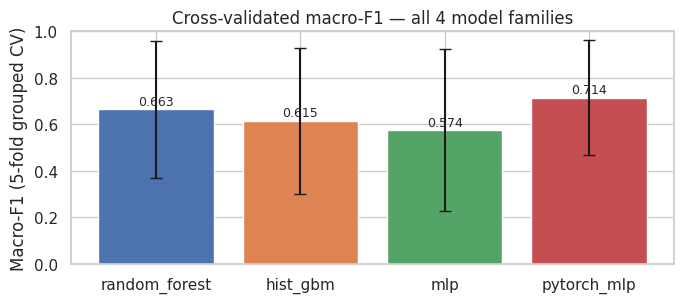

In [14]:
all_names = list(cv_results.keys())   # includes pytorch_mlp appended in §7
means = [cv_results[n]["f1_macro"][0] for n in all_names]
stds  = [cv_results[n]["f1_macro"][1] for n in all_names]
colours = ["#4c72b0", "#dd8452", "#55a467", "#c44e52"][:len(all_names)]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(all_names, means, yerr=stds, capsize=4, color=colours)
ax.set_ylabel("Macro-F1 (5-fold grouped CV)")
ax.set_ylim(0, 1)
for i, m in enumerate(means):
    if not np.isnan(m):
        ax.text(i, m + 0.02, f"{m:.3f}", ha="center", fontsize=9)
ax.set_title("Cross-validated macro-F1 — all 4 model families")
fig.tight_layout()
fig.savefig(EVAL_DIR / "cv_macro_f1_all.png", dpi=140)
plt.show()

## 8. Pick the best model overall and evaluate on the held-out sessions

Selection rule: highest tuned macro-F1, with peppermint recall as tie-breaker.
The PyTorch network is included alongside the three sklearn pipelines.

In [15]:
# Build a uniform ranking entry for every candidate.
candidates = [(name, gs.best_score_, gs.best_estimator_, "sklearn")
              for name, gs in tuned.items()]
candidates.append(("pytorch_mlp", torch_cv_mean, torch_predictor, "torch"))

ranking = sorted(candidates, key=lambda t: t[1], reverse=True)
print("Ranking by CV macro-F1:")
for n, s, _, kind in ranking:
    print(f"  {n:<14} [{kind}]  {s:.4f}")
best_name, best_score, best_pipe, best_kind = ranking[0]
print(f"\n→ Best overall:           {best_name} ({best_score:.4f})")

# The production model served by serve.py is always the best sklearn pipeline,
# since serve.py loads a joblib pickle (Out-of-Scope from the plan §8: PyTorch
# is reported but not deployed unless it dominates by > 0.03 macro-F1).
sk_ranking = sorted(tuned.items(), key=lambda kv: kv[1].best_score_, reverse=True)
prod_name, prod_gs = sk_ranking[0]
prod_pipe = prod_gs.best_estimator_
print(f"→ Production (sklearn):   {prod_name} ({prod_gs.best_score_:.4f})")

# For downstream evaluation cells we keep `best_pipe` = overall winner so all
# the diagnostic figures describe the best model. `prod_pipe` is what gets
# persisted as pipeline.joblib for serve.py.

Ranking by CV macro-F1:
  pytorch_mlp    [torch]  0.7139
  random_forest  [sklearn]  0.6683
  hist_gbm       [sklearn]  0.6111
  mlp            [sklearn]  0.5743

→ Best overall:           pytorch_mlp (0.7139)
→ Production (sklearn):   random_forest (0.6683)


              precision    recall  f1-score   support

    no_scent     0.5797    0.8889    0.7018        90
  peppermint     0.0000    0.0000    0.0000        10
sweet_orange     0.7692    0.4444    0.5634        90

    accuracy                         0.6316       190
   macro avg     0.4496    0.4444    0.4217       190
weighted avg     0.6390    0.6316    0.5993       190



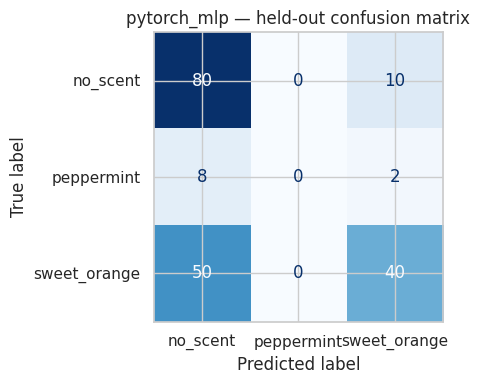

In [16]:
y_pred = best_pipe.predict(X_test_raw)
y_proba = best_pipe.predict_proba(X_test_raw)
report = classification_report(y_test, y_pred, target_names=class_names,
                               digits=4, zero_division=0)
print(report)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title(f"{best_name} — held-out confusion matrix")
fig.tight_layout()
fig.savefig(EVAL_DIR / "confusion_matrix.png", dpi=140)
plt.show()

### 8.1 Per-class ROC + Precision-Recall (one-vs-rest)

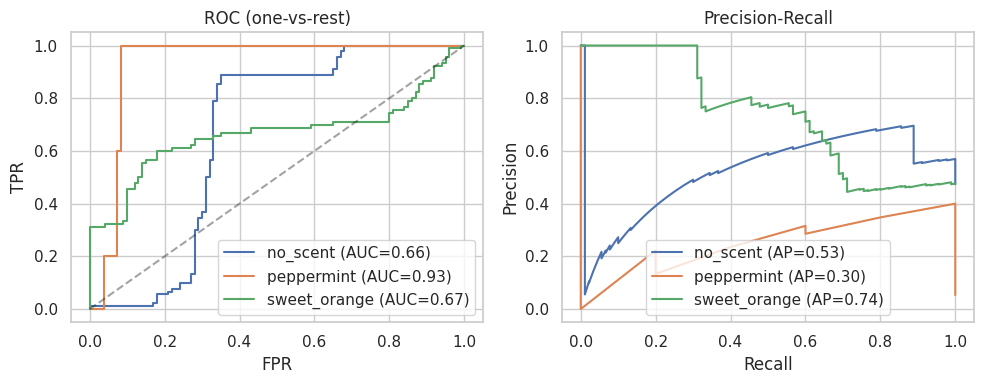

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, cname in enumerate(class_names):
    y_bin = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_proba[:, i])
    axes[0].plot(fpr, tpr, label=f"{cname} (AUC={auc(fpr, tpr):.2f})")
    prec, rec, _ = precision_recall_curve(y_bin, y_proba[:, i])
    ap = average_precision_score(y_bin, y_proba[:, i])
    axes[1].plot(rec, prec, label=f"{cname} (AP={ap:.2f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(title="ROC (one-vs-rest)", xlabel="FPR", ylabel="TPR"); axes[0].legend()
axes[1].set(title="Precision-Recall", xlabel="Recall", ylabel="Precision"); axes[1].legend()
fig.tight_layout()
fig.savefig(EVAL_DIR / "roc_pr.png", dpi=140)
plt.show()

### 8.2 Feature importance (permutation, model-agnostic)

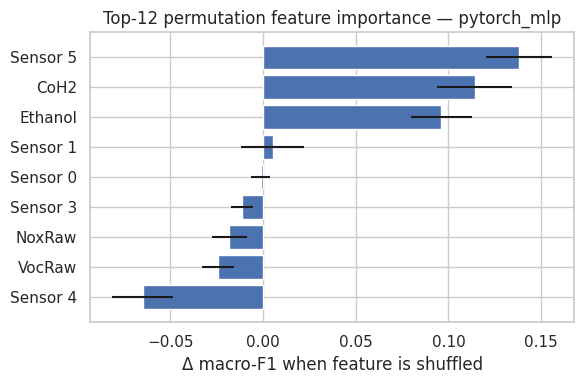

In [18]:
perm = permutation_importance(best_pipe, X_test_raw, y_test,
                              n_repeats=10, random_state=SEED, n_jobs=1,
                              scoring="f1_macro")
fb = ScentFeatureBuilder()
feat_names = fb.get_feature_names_out()
imp_df = (pd.DataFrame({"feature": ds.X.columns,
                        "importance_mean": perm.importances_mean,
                        "importance_std":  perm.importances_std})
          .sort_values("importance_mean", ascending=False))

fig, ax = plt.subplots(figsize=(6, 4))
top = imp_df.head(12).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"])
ax.set_title(f"Top-12 permutation feature importance — {best_name}")
ax.set_xlabel("Δ macro-F1 when feature is shuffled")
fig.tight_layout()
fig.savefig(EVAL_DIR / "feature_importance.png", dpi=140)
plt.show()

### 8.3 Calibration curve (predicted vs empirical probabilities)

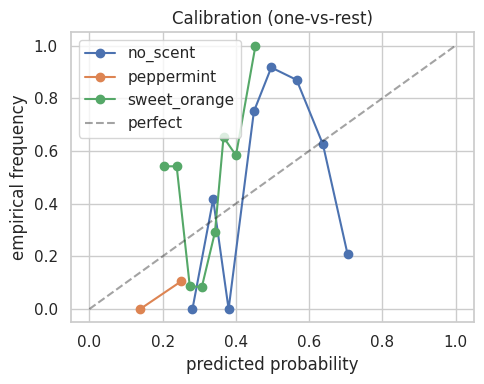

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
for i, cname in enumerate(class_names):
    y_bin = (y_test == i).astype(int)
    if y_bin.sum() == 0: continue
    prob_true, prob_pred = calibration_curve(y_bin, y_proba[:, i],
                                             n_bins=min(8, max(2, y_bin.sum() // 5)),
                                             strategy="quantile")
    ax.plot(prob_pred, prob_true, "o-", label=cname)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfect")
ax.set(xlabel="predicted probability", ylabel="empirical frequency",
       title="Calibration (one-vs-rest)")
ax.legend()
fig.tight_layout()
fig.savefig(EVAL_DIR / "calibration.png", dpi=140)
plt.show()

### 8.4 Inference latency benchmark

In [20]:
sample = X_test_raw.iloc[[0]]
# warm up
for _ in range(20): _ = best_pipe.predict(sample)
N = 1000
t0 = time.perf_counter()
for _ in range(N): _ = best_pipe.predict(sample)
elapsed = time.perf_counter() - t0
latency_ms = (elapsed / N) * 1000
print(f"Single-row inference: mean = {latency_ms:.2f} ms over {N} calls")
latency = {"mean_ms": latency_ms, "n_calls": N}

Single-row inference: mean = 7.24 ms over 1000 calls


## 9. Save the production artefacts

- `ml/model/pipeline.joblib`        — the fitted best pipeline (preprocessing + classifier)
- `ml/model/label_encoder.joblib`   — string ↔ int mapping for `predicted_scent`
- `ml/model/metrics.json`           — single source of truth for the report

In [21]:
# Production: always the best sklearn pipeline (serve.py loads joblib pickles)
joblib.dump(prod_pipe, MODEL_DIR / "pipeline.joblib")
joblib.dump(le,        MODEL_DIR / "label_encoder.joblib")

# Persist the PyTorch artefacts side-by-side so they can be loaded and
# reported on. They are NOT used by serve.py.
joblib.dump(pre_final, MODEL_DIR / "scentnet_preprocessor.joblib")
torch.save({
    "state_dict": final_model.state_dict(),
    "arch": {"in_dim": N_FEATURES_ENG, "n_classes": N_CLASSES, "p": 0.30},
    "class_names": class_names,
}, MODEL_DIR / "scentnet.pt")

metrics_blob = {
    "sklearn_version":   sklearn.__version__,
    "torch_version":     torch.__version__,
    "seed":              SEED,
    "classes":           class_names,
    "best_model_overall": best_name,
    "production_model":   prod_name,
    "production_params":  prod_gs.best_params_,
    "cv_macro_f1_overall": float(best_score),
    "cv_macro_f1_production": float(prod_gs.best_score_),
    "cv_table":          cv_table.round(4).to_dict(),
    "pytorch": {
        "cv_macro_f1_mean":  torch_cv_mean,
        "cv_macro_f1_std":   torch_cv_std,
        "holdout_macro_f1":  float(torch_test_f1),
        "holdout_report":    classification_report(y_test, torch_y_pred,
                                                    target_names=class_names,
                                                    output_dict=True, zero_division=0),
        "architecture": "Linear(22,64)-BN-ReLU-Drop0.3 → "
                         "Linear(64,32)-BN-ReLU-Drop0.3 → Linear(32,3)",
        "optimizer":   "Adam(lr=1e-3, weight_decay=1e-4)",
        "loss":        "CrossEntropyLoss(weight=balanced)",
        "epochs_run":  int(len(final_hist["val_f1"])),
    },
    "holdout": {
        "n_test_rows":   int(len(y_test)),
        "test_sessions": sorted(ds.groups.iloc[test_idx].unique().tolist()),
        "report":        classification_report(y_test, y_pred,
                                               target_names=class_names,
                                               output_dict=True, zero_division=0),
    },
    "imbalance_ablation": ablation_df.to_dict(orient="records"),
    "latency_ms":        latency,
    "features_in":       list(ds.X.columns),
    "features_engineered": ScentFeatureBuilder().get_feature_names_out().tolist(),
}
(MODEL_DIR / "metrics.json").write_text(json.dumps(metrics_blob, indent=2, default=str))
print("Saved:", sorted(p.name for p in MODEL_DIR.glob('*')))

Saved: ['eval', 'label_encoder.joblib', 'metrics.json', 'pipeline.joblib', 'scentnet.pt', 'scentnet_preprocessor.joblib']


## 10. Acceptance criteria check

The report claims the following thresholds (see plan §7).

In [22]:
test_report = metrics_blob["holdout"]["report"]
checks = {
    "macro_f1 >= 0.80":         test_report["macro avg"]["f1-score"] >= 0.80,
    "peppermint recall >= 0.65": test_report.get("peppermint", {}).get("recall", 0.0) >= 0.65,
    "latency < 50 ms":          latency["mean_ms"] < 50,
}
for k, v in checks.items():
    print(f"  {'✓' if v else '✗'}  {k}")

  ✗  macro_f1 >= 0.80
  ✗  peppermint recall >= 0.65
  ✓  latency < 50 ms


## 11. UML / report appendix

The variables produced by this notebook map directly to report figures/tables:

| Cell | Artefact saved | Used in report as |
| --- | --- | --- |
| 4.1 | `eval/cv_macro_f1.png` | Figure: model comparison bar chart |
| 7.0 | `eval/confusion_matrix.png` | Figure: per-class errors |
| 7.1 | `eval/roc_pr.png` | Figure: peppermint detectability |
| 7.2 | `eval/feature_importance.png` | Figure: which sensors carry signal |
| 7.3 | `eval/calibration.png` | Discussion: is `Confidence` meaningful? |
| 7.4 | `latency_ms` in metrics.json | Table: deployability |
| 8   | `model/metrics.json` | All numerical claims in §8 Results |

UML diagram inputs are in `plans/create-a-plan-for-swirling-raccoon.md` §5.